In [2]:
import os
import re
import unicodedata
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# HELPER FUNCTIONS

def normalize_river_name(name):
    """Cleans and standardizes river names to group them correctly."""
    if not isinstance(name, str):
        return "inconnu"
    
    name = name.lower().strip()
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                   if unicodedata.category(c) != 'Mn')
    
    corrections = {
        "la vuachere": "vuachere",
        "vuachere+riolet": "vuachere",
        "le flon": "flon",
        "la louve": "louve",
        "unknown": "inconnu",
        "le petit flon": "petitflon",
    }
    
    return corrections.get(name, name)

In [3]:
# PART 0: FILE DISCOVERY

data_folder = '.' + os.sep + 'data' + os.sep
if not os.path.exists(data_folder):
    print(f"Error: Could not find the folder '{data_folder}'. Please create it and add your files.")
    exit()

legacy_names = {
    'berney': 1831,
    'renove': 1888,
    'contemporain': 2021
}

time_periods = {}

# Getting all files in the data folder
for filename in os.listdir(data_folder):
    if not filename.endswith(('.gpkg', '.shp', '.geojson')):
        continue
        
    filepath = os.path.join(data_folder, filename)
    filename_lower = filename.lower()
    
    year = None
    match = re.search(r'\d{4}', filename)
    if match:
        year = int(match.group())
    else:
        for key, val in legacy_names.items():
            if key in filename_lower:
                year = val
                break
                
    if not year:
        continue 

    if year not in time_periods:
        time_periods[year] = {}
        
    if 'river' in filename_lower or 'riviere' in filename_lower:
        time_periods[year]['river'] = filepath
        print(f"Detected River data for {year}: {filename}")
    elif 'lake' in filename_lower or 'lac' in filename_lower or 'shore' in filename_lower:
        time_periods[year]['lake'] = filepath
        print(f"Detected Lake data for {year}: {filename}")

years = sorted(time_periods.keys())
print(f"\nChronology established: {years}\n")

Detected River data for 1831: berney_rivers.gpkg
Detected River data for 2021: contemporain_rivers.gpkg
Detected Lake data for 1831: berney_lake.gpkg
Detected Lake data for 2021: contemporain_lake.gpkg
Detected River data for 1959: 1959_rivers.gpkg
Detected River data for 1888: renove_river.gpkg
Detected Lake data for 1888: renove_lake.gpkg
Detected Lake data for 1959: 1959_lake.gpkg

Chronology established: [1831, 1888, 1959, 2021]



In [6]:
# PART 1: RIVER ANALYSIS

river_data = []
possible_name_columns = ['name', 'nom', 'riviere', 'nom_riviere', 'river_name', 'nom_riv']

for year in years:
    if 'river' not in time_periods[year]:
        print(f"No river data found for {year}. Skipping...")
        continue
        
    gdf = gpd.read_file(time_periods[year]['river']).to_crs(epsg=2056)
    gdf['length_m'] = gdf.geometry.length
    
    col_name = None
    for col in gdf.columns:
        if col.lower() in possible_name_columns:
            col_name = col
            break
            
    if not col_name:
        col_name = 'temp_name_col'
        gdf[col_name] = 'unknown'
    
    gdf['clean_name'] = gdf[col_name].apply(normalize_river_name)
    
    summed = gdf.groupby('clean_name')['length_m'].sum().reset_index()
    summed.rename(columns={'clean_name': 'river_name'}, inplace=True)
    summed['year'] = year
    river_data.append(summed)

if river_data:
    df_rivers = pd.concat(river_data)
    
    pivot_rivers = df_rivers.pivot(index='river_name', columns='year', values='length_m')

    available_river_years = sorted(df_rivers['year'].unique())
    for i in range(len(available_river_years) - 1):
        y1, y2 = available_river_years[i], available_river_years[i+1]
        time_gap = y2 - y1
        
        pivot_rivers[f'Lost_m_{y1}_to_{y2}'] = pivot_rivers[y1] - pivot_rivers[y2]
        
        pivot_rivers[f'Loss_%_{y1}_to_{y2}'] = np.where(
            (pivot_rivers[y1] > 0) & pivot_rivers[y1].notna() & pivot_rivers[y2].notna(), 
            (pivot_rivers[f'Lost_m_{y1}_to_{y2}'] / pivot_rivers[y1]) * 100, 
            np.nan
        )
        pivot_rivers[f'Rate_m_per_yr_{y1}_to_{y2}'] = pivot_rivers[f'Lost_m_{y1}_to_{y2}'] / time_gap

    pivot_rivers.round(2).to_csv('river_statistics2.csv')

In [7]:
# PART 2: LAKESHORE ANALYSIS

lake_gdfs = {}
for year in years:
    if 'lake' in time_periods[year]:
        gdf = gpd.read_file(time_periods[year]['lake']).to_crs(epsg=2056)
        lake_gdfs[year] = gdf.geometry.unary_union 

lake_stats = []
available_lake_years = sorted(lake_gdfs.keys())

if len(available_lake_years) > 1:
    for i in range(len(available_lake_years) - 1):
        y1, y2 = available_lake_years[i], available_lake_years[i+1]
        
        max_dist = lake_gdfs[y1].hausdorff_distance(lake_gdfs[y2])
        
        lake_stats.append({
            'Period': f'{y1} to {y2}',
            'Max_Displacement_m': max_dist
        })

    start_y, end_y = available_lake_years[0], available_lake_years[-1]
    total_dist = lake_gdfs[start_y].hausdorff_distance(lake_gdfs[end_y])

    lake_stats.append({
        'Period': f'TOTAL ({start_y} to {end_y})',
        'Max_Displacement_m': total_dist
    })

    df_lake = pd.DataFrame(lake_stats)
    print("Saving lakeshore_statistics.csv...")
    df_lake.round(2).to_csv('lakeshore_statistics.csv', index=False)

Saving lakeshore_statistics.csv...


/var/folders/8w/w7r8nwlj0g7fblnwv33g8jn80000gn/T/ipykernel_95310/3155507429.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lake_gdfs[year] = gdf.geometry.unary_union
/var/folders/8w/w7r8nwlj0g7fblnwv33g8jn80000gn/T/ipykernel_95310/3155507429.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lake_gdfs[year] = gdf.geometry.unary_union
/var/folders/8w/w7r8nwlj0g7fblnwv33g8jn80000gn/T/ipykernel_95310/3155507429.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lake_gdfs[year] = gdf.geometry.unary_union
/var/folders/8w/w7r8nwlj0g7fblnwv33g8jn80000gn/T/ipykernel_95310/3155507429.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lake_gdfs[year] = gdf.geometry.unary_union



=== RIVER LENGTHS BY YEAR (Meters) ===
year        1831  1888  1959  2021
river_name                        
boveresses   765   767  <NA>  <NA>
flon        5898  5491   104   116
galicien      28  <NA>  <NA>  <NA>
le rionzi   <NA>  <NA>  <NA>   210
louve       2321  1501   446   339
petitflon    603  <NA>   652   686
vuachere    3313  3372  2756  2793

=== LAKESHORE DISPLACEMENT ===
              Period  Max_Displacement_m
        1831 to 1888          162.769517
        1888 to 1959          156.410671
        1959 to 2021          254.756952
TOTAL (1831 to 2021)          290.367079


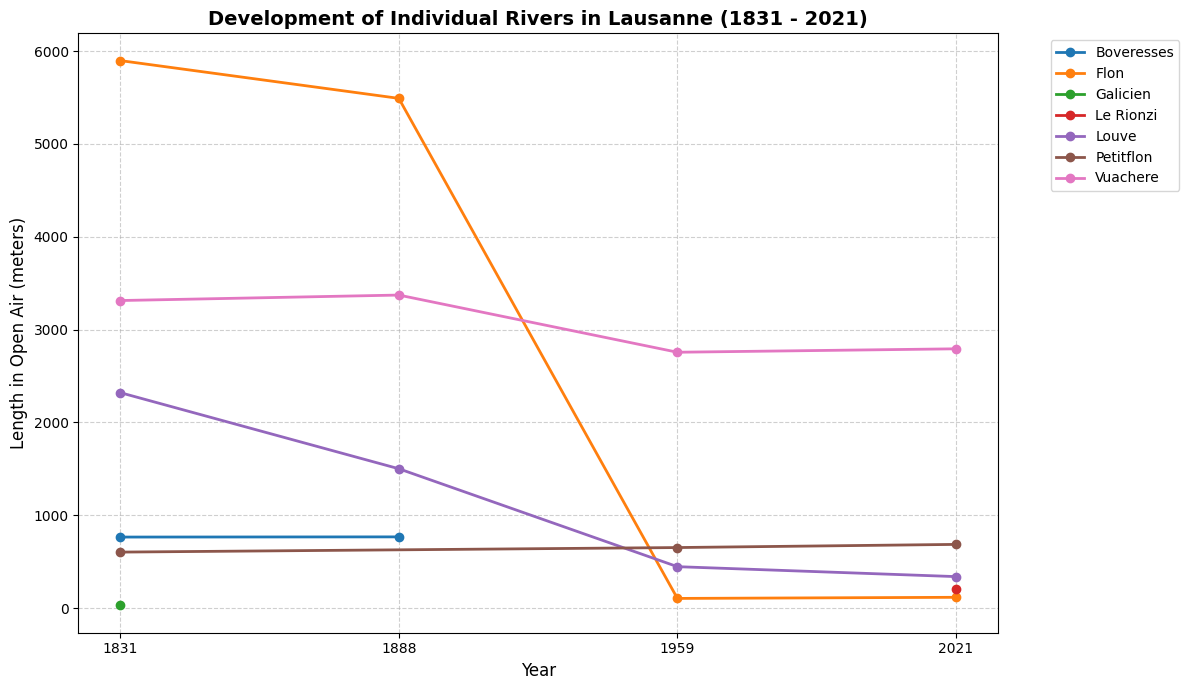

In [8]:
# PART 3: DATA VISUALIZATION & TABLES

print("\n=== RIVER LENGTHS BY YEAR (Meters) ===")
if river_data:
    clean_river_table = pivot_rivers[years].round(0).astype('Int64')
    
    # Drop unknown rivers
    rivers_to_drop = ['inconnu', 'unknown', 'temp_name_col']
    for drop_name in rivers_to_drop:
        if drop_name in clean_river_table.index:
            clean_river_table = clean_river_table.drop(drop_name)
            
    print(clean_river_table.to_string(na_rep='<NA>'))
else:
    print("No river data to display.")


print("\n=== LAKESHORE DISPLACEMENT ===")
if lake_stats:
    print(df_lake.to_string(index=False))
else:
    print("No lakeshore data to display.")


if river_data:
    plt.figure(figsize=(12, 7))
    
    for river in clean_river_table.index:
        row = clean_river_table.loc[river].dropna()
        
        if not row.empty:
            plt.plot(row.index.astype(str), 
                     row.values, 
                     marker='o', 
                     linewidth=2, 
                     label=river.title())

    plt.title('Development of Individual Rivers in Lausanne (1831 - 2021)', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Length in Open Air (meters)', fontsize=12)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    
    plt.show()